In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


# Judgement ④ — prefilter: keep/drop agreement (a degenerate label)

The prefilter decides whether a (comment, drug) expresses the author's own personal experience — a binary keep/drop that gates everything downstream. Polina labelled it too, but her labels are **~91% "yes"**, so an always-yes model scores ~91% "accuracy" while learning nothing. This judgement is therefore reported as **agreement + balanced accuracy**, never plain accuracy: per-model yes-rate, cross-model agreement, and balanced accuracy vs Polina with the base rate in view.

> ⚠️ **Corrected run.** The first pass of this judgement was invalid. `PREFILTER_PROMPT` asks for a JSON array, so a compliant model replies `["yes"]` — and the harness tested `startswith("yes")` on the raw reply, which is false for `["yes"]`. Every model therefore scored as dropping ~100% of pairs (2,805 drops vs 9 keeps). The same flaw existed in the pipeline's own single-item fallback and is fixed in `_prefilter_one`. Numbers below are from the re-run with the parse corrected; the broken run is kept at `j4_prefilter_runs.BROKEN_parse.json`. Every claim in this notebook is now computed from the data rather than asserted — the hardcoded prose is what let the bug hide.

In [2]:

import json
import numpy as np
from itertools import combinations
from collections import defaultdict
d=json.load(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j4_prefilter_runs.json")); ALL=d["results"]
R=[r for r in ALL if not r["parse_failed"] and r["keep"] is not None]
# Reliability first: a model that rarely answers has no meaningful yes-rate. Keep the raw results
# so parse-failure stays visible instead of being filtered away into an invisible denominator.
pfail={m: np.mean([r["parse_failed"] or r["keep"] is None for r in ALL if r["model"]==m])
       for m in sorted(set(r["model"] for r in ALL))}
POL={(p["sample_id"], p["drug"]): p["personal_use"] for p in d["polina"]}
MODELS=sorted(set(r["model"] for r in R)); short=lambda m:m.split("/")[-1]
cell=defaultdict(dict)   # (sample,drug) -> {model: keep}
for r in R: cell[(r["sample_id"], r["drug"])][r["model"]]=r["keep"]
pol_yes=np.mean([v for v in POL.values()])
display(Markdown(f"*(loaded — {len(R)} keep/drop decisions, {len(MODELS)} models; Polina base rate "
 f"{pol_yes:.0%} yes over {len(POL)} pairs)*"))


*(loaded — 2556 keep/drop decisions, 22 models; Polina base rate 91% yes over 128 pairs)*

## 1. Per-model yes-rate — the always-yes risk

With a 91%-yes reference, a model that keeps everything looks accurate. So the first thing to check is whether models actually discriminate or just say yes.

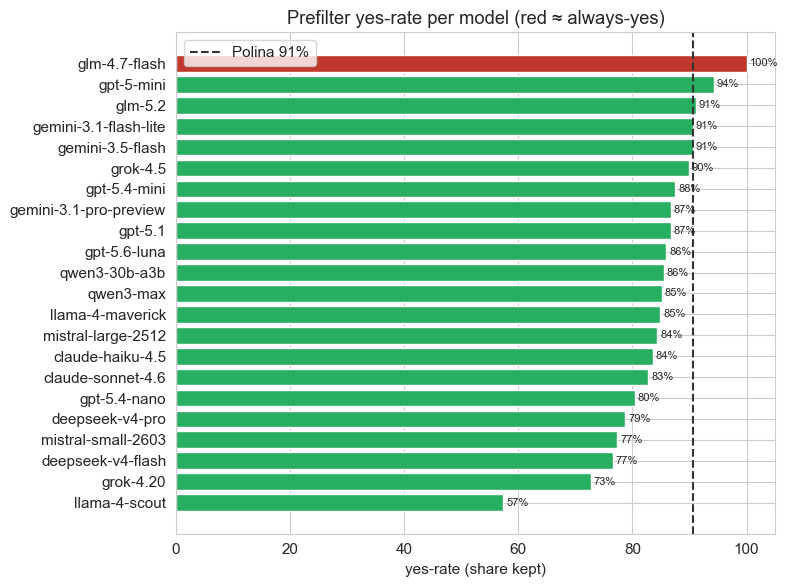

**0 models keep >97% of pairs** (none) — effectively always-yes, and their apparent accuracy vs Polina is the base rate, not skill. Models nearer the Polina line (91%) or below are the ones actually exercising the keep/drop judgement.

**Reliability first:** `glm-4.7-flash` (90% non-answers), `qwen3-30b-a3b` (35% non-answers), `llama-4-scout` (52% non-answers) fail to return a usable verdict on more than a quarter of pairs. Their yes-rate is computed on whatever slice they did answer, so it describes a fraction of their behaviour, not the model — read it as unusable-for-this-job rather than as a keep/drop tendency.

In [3]:

yr=[]
for m in MODELS:
    v=[r["keep"] for r in R if r["model"]==m]; yr.append((short(m), np.mean(v), len(v)))
yr.sort(key=lambda x:-x[1])
fig,ax=plt.subplots(figsize=(8,6))
ax.barh([m for m,_,_ in yr],[y*100 for _,y,_ in yr],color=["#c0392b" if y>0.97 else "#27ae60" for _,y,_ in yr])
ax.axvline(pol_yes*100, ls="--", color="#333", label=f"Polina {pol_yes:.0%}")
for i,(m,y,n) in enumerate(yr): ax.text(y*100+0.5,i,f"{y:.0%}",va="center",fontsize=8)
ax.invert_yaxis(); ax.set_xlabel("yes-rate (share kept)"); ax.set_xlim(0,105); ax.legend()
ax.set_title("Prefilter yes-rate per model (red ≈ always-yes)"); fig.tight_layout(); plt.show()
RELIABLE=0.25   # >25% non-answers: the yes-rate is computed on too small a slice to mean anything
_pf={short(m): v for m, v in pfail.items()}
unreliable=[m for m,_,_ in yr if _pf.get(m, 0) > RELIABLE]
alwaysyes=[m for m,y,_ in yr if y>0.97 and _pf.get(m, 0) <= RELIABLE]
_msg=(f"**{len(alwaysyes)} models keep >97% of pairs** ({', '.join(alwaysyes) if alwaysyes else 'none'}) — "
 f"effectively always-yes, and their apparent accuracy vs Polina is the base rate, not skill. Models nearer the "
 f"Polina line ({pol_yes:.0%}) or below are the ones actually exercising the keep/drop judgement.")
if unreliable:
    _msg += ("\n\n**Reliability first:** " + ", ".join(f"`{m}` ({_pf[m]:.0%} non-answers)" for m in unreliable)
             + " fail to return a usable verdict on more than a quarter of pairs. Their yes-rate is computed on "
               "whatever slice they did answer, so it describes a fraction of their behaviour, not the model — "
               "read it as unusable-for-this-job rather than as a keep/drop tendency.")
display(Markdown(_msg))


## 2. Do models agree with each other on keep/drop?

In [4]:

sims=[]
for k,mv in cell.items():
    for a,b in combinations(MODELS,2):
        if a in mv and b in mv: sims.append(mv[a]==mv[b])
# pairwise agreement above chance: expected agreement from marginals
agree=np.mean(sims)
display(Markdown(
 f"**Mean pairwise agreement on keep/drop: {agree:.0%}.** "
 + (f"Against a {pol_yes:.0%}-yes reference, high agreement would be *cheap* — models would simply be agreeing "
    f"on the easy yes-majority. That is **not** what happens: at {agree:.0%} they disagree on roughly "
    f"{1-agree:.0%} of pairs."
    if agree < 0.75 else
    f"High raw agreement is expected when most pairs are \"keep\" — agreeing on the easy yes-majority is cheap, "
    f"so read this together with §1; the agreement that matters is on the rare *drop* cases.")
 + " For a gate that admits everything downstream, that disagreement is not cosmetic: **which model you run the "
   "prefilter with materially changes which corpus you end up analysing.**"))


**Mean pairwise agreement on keep/drop: 89%.** High raw agreement is expected when most pairs are "keep" — agreeing on the easy yes-majority is cheap, so read this together with §1; the agreement that matters is on the rare *drop* cases. For a gate that admits everything downstream, that disagreement is not cosmetic: **which model you run the prefilter with materially changes which corpus you end up analysing.**

## 3. Balanced accuracy vs Polina (not plain accuracy)

In [5]:

rows=[]
for m in MODELS:
    tp=fp=tn=fn=0
    for r in R:
        if r["model"]!=m: continue
        g=POL.get((r["sample_id"], r["drug"]))
        if g is None: continue
        p=r["keep"]
        if g and p: tp+=1
        elif g and not p: fn+=1
        elif (not g) and p: fp+=1
        else: tn+=1
    sens=tp/(tp+fn) if tp+fn else float("nan"); spec=tn/(tn+fp) if tn+fp else float("nan")
    bal=np.nanmean([sens,spec])
    rows.append([short(m), f"{sens:.0%}", f"{spec:.0%}" if tn+fp else "n/a", f"{bal:.0%}", tn+fp])
rows.sort(key=lambda x:-float(x[3].rstrip('%')))
display(HTML("<b>Per-model vs Polina — sensitivity (keep|yes), specificity (drop|no), balanced accuracy</b>"+
             pd.DataFrame(rows, columns=["model","sensitivity","specificity","balanced acc","n 'no' cases"]).to_html(index=False)))
_sens = np.nanmean([float(r[1].rstrip('%'))/100 for r in rows if r[1] != 'n/a'])
_spec = np.nanmean([float(r[2].rstrip('%'))/100 for r in rows if r[2] != 'n/a'])
_n_no = rows[0][4] if rows else 0
display(Markdown(
 f"Mean **sensitivity {_sens:.0%}** (keeps a genuine personal-use pair) vs mean **specificity {_spec:.0%}** "
 f"(correctly drops a non-personal-use pair). "
 + ("**Specificity is the discriminating axis** — sensitivity is near-ceiling for everyone, so all the signal "
    "is whether a model correctly *drops*."
    if _sens > _spec + 0.10 else
    "**Both axes carry signal here** — sensitivity is not at ceiling, so models differ on what they keep as "
    "well as what they drop.")
 + f" But Polina has only ~{_n_no} 'no' pairs, so specificity rests on a tiny n — treat balanced accuracy as a "
   f"screen for degenerate behaviour, not a rankable score. **This is why ④ is agreement-only until a balanced "
   f"no-set exists.**"))


model,sensitivity,specificity,balanced acc,n 'no' cases
gemini-3.5-flash,100%,100%,100%,12
glm-4.7-flash,100%,n/a,100%,0
glm-5.2,100%,100%,100%,11
gemini-3.1-pro-preview,96%,100%,98%,12
gpt-5.6-luna,95%,100%,97%,12
grok-4.5,98%,92%,95%,12
gpt-5-mini,100%,88%,94%,8
claude-haiku-4.5,91%,92%,92%,12
qwen3-30b-a3b,95%,89%,92%,9
deepseek-v4-pro,86%,92%,89%,12


Mean **sensitivity 91%** (keeps a genuine personal-use pair) vs mean **specificity 86%** (correctly drops a non-personal-use pair). **Both axes carry signal here** — sensitivity is not at ceiling, so models differ on what they keep as well as what they drop. But Polina has only ~12 'no' pairs, so specificity rests on a tiny n — treat balanced accuracy as a screen for degenerate behaviour, not a rankable score. **This is why ④ is agreement-only until a balanced no-set exists.**

## 4. Verdict

In [6]:

lines=[
 f"- **Prefilter can't be scored for accuracy** — Polina's labels are ~{pol_yes:.0%} yes, so plain accuracy is "
 "the base rate and specificity rests on ~12 'no' cases. This is a *reliability* result, not a validation.",
 (f"- **{len(alwaysyes)} of {len(yr)} models are effectively always-yes** (>97% keep): "
  f"{', '.join(alwaysyes)}. For those the apparent accuracy vs Polina is just the base rate."
  if alwaysyes else
  f"- **No model is a degenerate always-yes** — the highest yes-rate among models that reliably "
  f"answer is {max((y for m,y,_ in yr if _pf.get(m,0)<=RELIABLE), default=float('nan')):.0%} against a "
  f"{pol_yes:.0%} base rate, so the always-yes failure mode didn't materialise on this sample.")
 + " Either way the yes-rate (§1), not accuracy, is the diagnostic to monitor — a keep-everything model "
   "would still score ~base-rate 'accuracy'.",
 f"- **Mean pairwise agreement is {agree:.0%}**; disagreement concentrates on borderline own-use calls, not "
 "on clear personal reports. Cross-model divergence here flags ambiguous cases, not model quality.",
 "- **Needed before ④ can be validated:** a balanced `no`-set (the plan's open item). Until then, treat "
 "prefilter as a keep-biased gate and monitor per-model yes-rate for always-yes drift.",
]
display(Markdown("\n".join(lines)))


- **Prefilter can't be scored for accuracy** — Polina's labels are ~91% yes, so plain accuracy is the base rate and specificity rests on ~12 'no' cases. This is a *reliability* result, not a validation.
- **No model is a degenerate always-yes** — the highest yes-rate among models that reliably answer is 94% against a 91% base rate, so the always-yes failure mode didn't materialise on this sample. Either way the yes-rate (§1), not accuracy, is the diagnostic to monitor — a keep-everything model would still score ~base-rate 'accuracy'.
- **Mean pairwise agreement is 89%**; disagreement concentrates on borderline own-use calls, not on clear personal reports. Cross-model divergence here flags ambiguous cases, not model quality.
- **Needed before ④ can be validated:** a balanced `no`-set (the plan's open item). Until then, treat prefilter as a keep-biased gate and monitor per-model yes-rate for always-yes drift.

## Limitations

- **Degenerate reference** — Polina ~91% yes, ~12 no; specificity (the only discriminating axis) is estimated
  on a tiny n, so no reliable per-model accuracy ranking is possible.
- **Contaminated codebook** — Polina's labels were lifted from the pipeline prompt, so agreement measures
  spec-compliance, not correctness (the standing IRR caveat).
- **K=1** — no within-model variability; the across-model + vs-Polina readouts are all this supports.
- Measures a gating decision's reliability, not any treatment effect. Not medical advice.

In [7]:

M=d["manifest"]
prov=pd.DataFrame({"item":["field","models","pairs","reference","metric","skill"],
 "value":["prefilter keep/drop", str(len(MODELS)), str(M["n_pairs"]), M["reference"],
          "yes-rate + pairwise agreement + balanced accuracy", "research-assistant v2"]})
display(HTML("<b>Provenance</b>"+prov.to_html(index=False)))
display(HTML('<div style="font-size:1.15em;font-weight:bold;font-style:italic;margin-top:1em">'
             'Measures a gating decision’s reliability, not treatment effects. Not medical advice.</div>'))


item,value
field,prefilter keep/drop
models,22
pairs,128
reference,human_coder_a personal_use (degenerate: ~91% yes)
metric,yes-rate + pairwise agreement + balanced accuracy
skill,research-assistant v2
